In [1]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv('../data/widget_sales.csv')

df.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


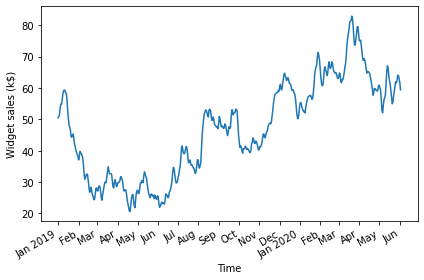

In [3]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F01_peixeiro.png', dpi=300)

- From  above chart we can see that , We can intuitively say that this time series is not a stationary process, since we can observe a trend over time. 
- Furthermore, there is no apparent cyclical pattern in the data, so we can rule out any seasonal effects for now.
- Once the data is gathered, we will test for stationarity. If it is not stationary, we will apply a transformation to make it stationary. Then, once the series is a stationary process, we will plot the autocorrelation function (ACF)

In [3]:
ADF_result = adfuller(df['widget_sales'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -1.5121662069359039
p-value: 0.527484535227261


- Here, the ADF statistic is not a large negative number, and the p-value is greater than 0.05. Therefore, our time series is not stationary, and we must apply transformations to make it stationary.

In [4]:
# take the first order difference of the widget sales to make the time series stationary
widget_sales_diff = np.diff(df['widget_sales'], n=1)

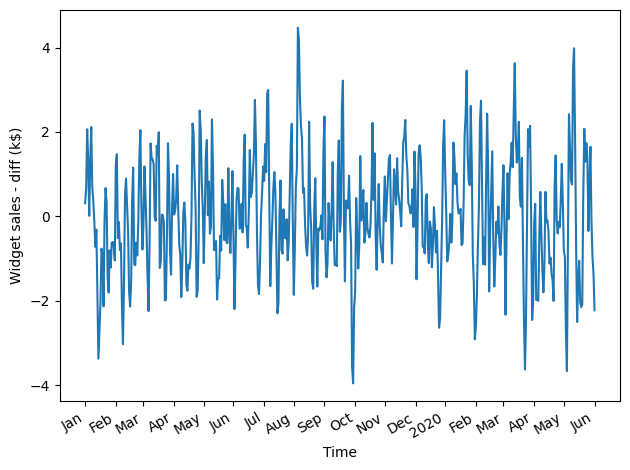

In [5]:
fig, ax = plt.subplots()

ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F05_peixeiro.png', dpi=300)

In [6]:
ADF_result = adfuller(widget_sales_diff)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -10.576657780341954
p-value: 7.076922818587447e-19


- This gives an ADF statistic of –10.6 and a p-value of 7 × 10–19. Therefore, with a large negative ADF statistic and a p-value much smaller than 0.05, we can say that our series is stationary.


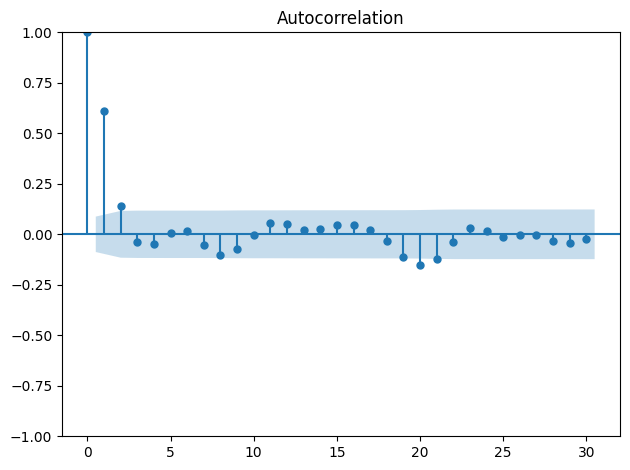

In [15]:
plot_acf(widget_sales_diff, lags=30);

plt.tight_layout()

plt.savefig('figures/CH04_F06_peixeiro.png', dpi=300)

### Moving average process
- In a moving average (MA) process, the current value depends linearly on the mean of the series, the current error term, and past error terms.
- The moving average model is denoted as **MA(q)**, where q is the order
- The general expression of an MA(q) model is
yt = μ + εt + 𝜃1εt-1 + 𝜃2εt-2 + 𝜃3εt-3 + .... + 𝜃qεt-q
    - μ is the mean of the series
    - εt current error term
    - εt-1 previous error term.
    - εt-q past error terms.
    - 𝜃1 ...𝜃q : are the co-efficient of the error term.

- The order q of the moving average model determines the number of past error terms that affect the present value.

- So if we have a moving Average process of order 2, MA(2) then yt is depend upon the μ (the mean of the series) + previous timestamp error term  and error term of 2 timestamp before.

- **The larger q is, the more past error terms affect the present value.**


### Identifying the order of a moving average process
- the first step is to gather the data. 
- Then we test for stationarity. 
- If our series is not stationary, we apply transformations, such as differencing, until the series is stationary. 
- Then we plot the ACF and look for significant autocorrelation coefficients. 
- In the case of a random walk, we will not see significant coefficients after lag 0. 
- On the other hand, if we see significant coefficients, we must check whether they become abruptly non-significant after some lag q. 
    - If that is the case, then we know that we have a moving average process of order q

### ACF plot helps us determine the order of a moving average process
- In the above  acf plot
- You’ll notice that there are significant coefficients up until lag 2. 
- Then they abruptly become non-significant, as they remain in the shaded area of the plot. 
- This means that we have a stationary moving average process of order 2. 
- We can use a second-order moving average model, or MA(2) model, to forecast our stationary time series.

In [16]:
df_diff = pd.DataFrame({'widget_sales_diff': widget_sales_diff})

train = df_diff[:int(0.9*len(df_diff))] # use the first 90% of the data for training and the remaining 10% for testing
test = df_diff[int(0.9*len(df_diff)):] # use the last 10% of the data for testing

print(len(train))
print(len(test))

449
50


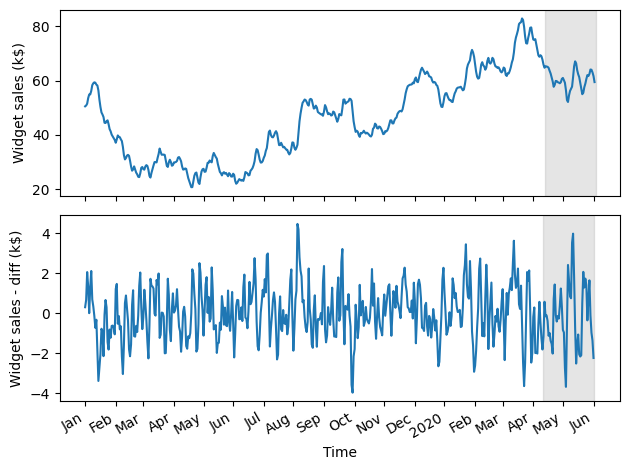

In [17]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)

ax1.plot(df['widget_sales'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color='#808080', alpha=0.2) # highlight the period for the test data 450 to 500.

ax2.plot(df_diff['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales - diff (k$)')
ax2.axvspan(449, 498, color='#808080', alpha=0.2) # highlight the period for the test data 449 to 498, which is the same period as the test data in the original time series but shifted by one timestep due to the differencing.

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F07_peixeiro.png', dpi=300)

### Issue with MA
- The MA(q) model does not allow us to forecast 50 steps into the future in one shot. 
- Remember that the moving average model is linearly dependent on past error terms, and those terms are not observed in the dataset—they must therefore be recursively estimated.
- This means that for an MA(q) model, we can only forecast q steps into the future. 
- Any prediction made beyond that point will not have past error terms, and the model will only predict the mean.
- Therefore, there is no added value in forecasting beyond q steps into the future, because the predictions will fall flat, as only the mean is returned, which is equivalent to a baseline model.

### Solution

- To avoid simply predicting the mean beyond two timesteps into the future, we need to develop a function that will predict two timesteps or less at a time, until 50 predictions are made. (as our test is 50 data points)
- This method is called **rolling forecasts**. On the first pass, we will train on the first 449 timesteps and predict timesteps 450 and 451. 
- Then, on the second pass, we will train on the first 451 timesteps, and predict timesteps 452 and 453. This is repeated until we finally predict the values at timesteps 498 and 499.


### SARIMAX method
- SARIMAX is a complex model that allows us to consider seasonal effects, autoregressive processes, non-stationary time series, moving average processes, and exogenous variables all in a single model. For now, we will disregard all factors except the moving average portion.


In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    
    if method == 'mean':
        pred_mean = []
        
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))

        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'MA':
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_MA.extend(oos_pred)
            
        return pred_MA

In [19]:
pred_df = test.copy()

TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA')

pred_df['pred_mean'] = pred_mean
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_MA'] = pred_MA

pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


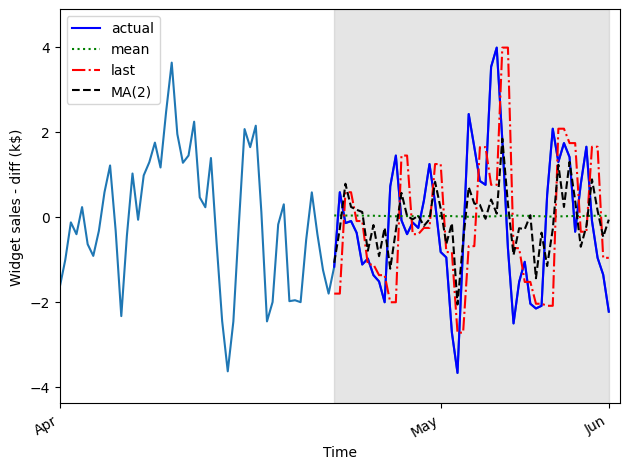

In [21]:
fig, ax = plt.subplots()

ax.plot(df_diff['widget_sales_diff'])
ax.plot(pred_df['widget_sales_diff'], 'b-', label='actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_last_value'], 'r-.', label='last')
ax.plot(pred_df['pred_MA'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

ax.axvspan(449, 498, color='#808080', alpha=0.2)

ax.set_xlim(400, 500)

plt.xticks(
    [400, 468, 498], 
    ['Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F08_peixeiro.png', dpi=300)

In [22]:
# measure the performance of the three forecasting methods using mean squared error (MSE)
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean'])
mse_last = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value'])
mse_MA = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_MA'])

print(mse_mean, mse_last, mse_MA)

2.5606299456880532 3.2494260812249225 1.9481714497641685


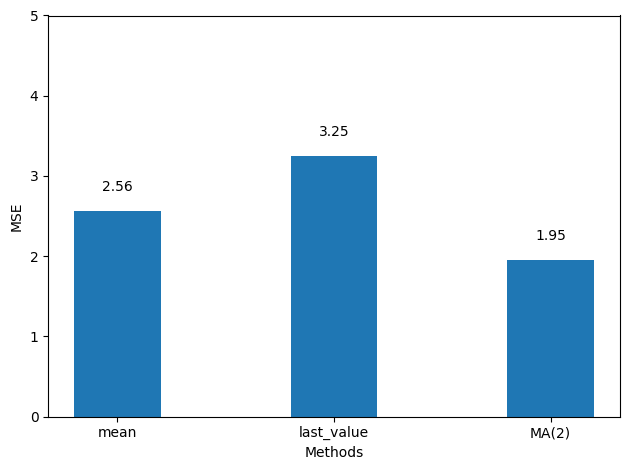

In [23]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

plt.savefig('figures/CH04_F09_peixeiro.png', dpi=300)

### Getting the Actual Prediction value back
- As we have made our series stationary by taking the difference. Now Once our model predict, we need to inverse it back to get the actual predicted value back.
- the reverse of difference is **.cumsum()** we will use this method to inverse it back. 

In [24]:
df['pred_widget_sales'] = pd.Series()
df['pred_widget_sales'][450:] = df['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum()

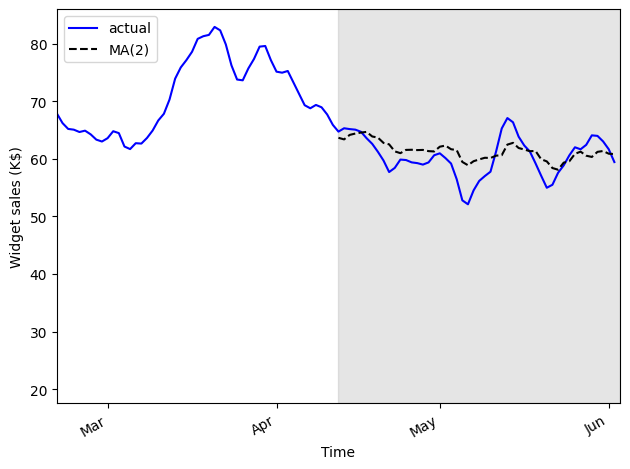

In [25]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'], 'b-', label='actual')
ax.plot(df['pred_widget_sales'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (K$)')

ax.axvspan(450, 500, color='#808080', alpha=0.2)

ax.set_xlim(400, 500)

plt.xticks(
    [409, 439, 468, 498], 
    ['Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH04_F11_peixeiro.png', dpi=300)

In [26]:
from sklearn.metrics import mean_absolute_error

# Lets measure the performance of the MA(2) model in the original time series using mean absolute error (MAE)
mae_MA_undiff = mean_absolute_error(df['widget_sales'].iloc[450:], df['pred_widget_sales'].iloc[450:])

print(mae_MA_undiff)

2.324470924435662


- This prints out an MAE of 2.32. Therefore, our predictions are, on average, off by $2,320, either above or below the actual value. 
- Remember that our data has units of thousands of dollars, so we multiply the MAE by 1,000 to express the average absolute difference.
- When we see a **sinusoidal pattern in the ACF plot of a stationary process**, this is a hint that an **autoregressive process** is at play, and we must use an AR(p) model to produce our forecast. Just like the **MA(q) model**, the **AR(p) model** will require us to identify its order. 
- This time we will have to plot the partial autocorrelation function and see at which lag the coefficients suddenly become non-significant.

- In moving average process, also denoted as MA(q), where q is the order. We learned that in a moving average process, the pres- ent value is linearly dependent on current and past error terms.

- Therefore, if you predict more than q steps ahead, the prediction will fall flat and will return only the mean of the series, because the error terms are not observed in the data and must be recursively estimated